In [1]:
# Select the free GPU. MUST run before torch is imported (i.e. before every
# other cell), otherwise CUDA is already bound to GPU 0.
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # GPU 1 is free; "cuda" now maps to it

# 04 — Variant 4: CycleGAN (unpaired)

Trained WITHOUT pairing information: sketch and color images are sampled
independently (`paired=False` in the dataset) to simulate the unpaired
setting. Pairs are used only at evaluation time (SSIM/PSNR vs ground truth).

Direct comparison against Pix2Pix quantifies the value of paired supervision.

## Configuration

In [2]:
import sys
sys.path.append("..")

from src.data import AnimeColorizationDataset
from src.training import CycleGANTrainer
from src.utils import seed_everything, plot_loss_curves, qualitative_grid, evaluate_model

seed_everything(42)

DATA_ROOT   = "../data/anime_colorization"
CKPT_DIR    = "../checkpoints/cyclegan"
FIGURES_DIR = "../results/figures/cyclegan"
TABLES_DIR  = "../results/tables"

CONFIG = dict(
    image_size=256,
    batch_size=8,          # CycleGAN is heavy (2 G + 2 D); 8 fits in 24 GB with AMP
    num_workers=4,
    epochs=50,             # 14k imgs/epoch >> the paper's ~1k dataset, so far fewer
                           # epochs are needed; also matches variants 1-3 (fair comparison)
    decay_start=25,        # constant LR for 25 epochs, then linear decay to 0
    lr=2e-4,
    lambda_cycle=10.0,
    lambda_identity=5.0,
    use_amp=True,          # fp16 autocast + GradScaler (~2x faster on the RTX 3090)
)

## Dataloaders

Training uses `paired=False`: sketch and color images are shuffled independently
via a fixed random permutation so the model sees no pairing signal.
Validation and test use `paired=True` to evaluate against ground-truth colors.

In [3]:
from torch.utils.data import DataLoader

train_ds = AnimeColorizationDataset(
    DATA_ROOT, split="train",
    image_size=CONFIG["image_size"], paired=False)
val_ds   = AnimeColorizationDataset(
    DATA_ROOT, split="val",
    image_size=CONFIG["image_size"], paired=True)
test_ds  = AnimeColorizationDataset(
    DATA_ROOT, split="test",
    image_size=CONFIG["image_size"], paired=True)

train_loader = DataLoader(
    train_ds, batch_size=CONFIG["batch_size"],
    shuffle=True,  num_workers=CONFIG["num_workers"], pin_memory=True)
val_loader   = DataLoader(
    val_ds,   batch_size=CONFIG["batch_size"],
    shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)
test_loader  = DataLoader(
    test_ds,  batch_size=CONFIG["batch_size"],
    shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)

print(f"train: {len(train_ds):,} images")
print(f"val:   {len(val_ds):,} images")
print(f"test:  {len(test_ds):,} images")

train: 14,224 images
val:   1,772 images
test:  1,773 images


## Training

Training is run **headless** via `scripts/train_cyclegan.py` (resumable +
auto-retry on the shared GPU — see the README). This notebook only *loads* the
checkpoints it produced, so it never needs the long training run.

In [4]:
trainer = CycleGANTrainer(
    train_loader=train_loader,
    val_loader=val_loader,
    checkpoint_dir=CKPT_DIR,
    monitor="val_l1",
    device="cuda",
    lambda_cycle=CONFIG["lambda_cycle"],
    lambda_identity=CONFIG["lambda_identity"],
    lr=CONFIG["lr"],
    decay_start=CONFIG["decay_start"],
    use_amp=CONFIG["use_amp"],
)

# last.pt holds the full training history (used for the loss curves below);
# best.pt (loaded later for the grid/metrics) holds the best weights by val_l1.
trainer.load_checkpoint("last.pt")
history = trainer.history
print(f"Loaded checkpoint at epoch {trainer.epoch}/{CONFIG['epochs']} "
      f"| best val_l1 = {trainer.best_metric:.4f}")

# To train inside the notebook instead (not recommended on the shared GPU):
# history = trainer.fit(CONFIG["epochs"])

Loaded checkpoint at epoch 50/50 | best val_l1 = 0.1838


## Loss curves

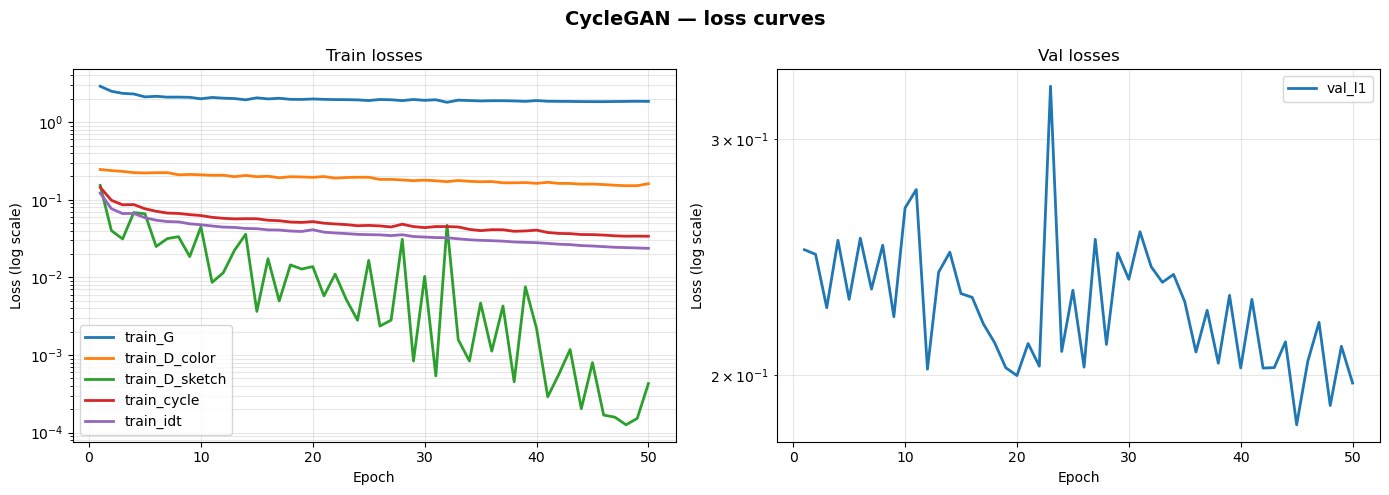

In [5]:
import json
from pathlib import Path

Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)

# Save history for the cross-variant comparison notebook
Path(TABLES_DIR).mkdir(parents=True, exist_ok=True)
with open(f"{TABLES_DIR}/cyclegan_history.json", "w") as f:
    json.dump(history, f)

plot_loss_curves(
    history,
    title="CycleGAN — loss curves",
    save_path=f"{FIGURES_DIR}/loss_curves.png",
)

## Qualitative grid

Load the best checkpoint and run inference on a sample from the test set.

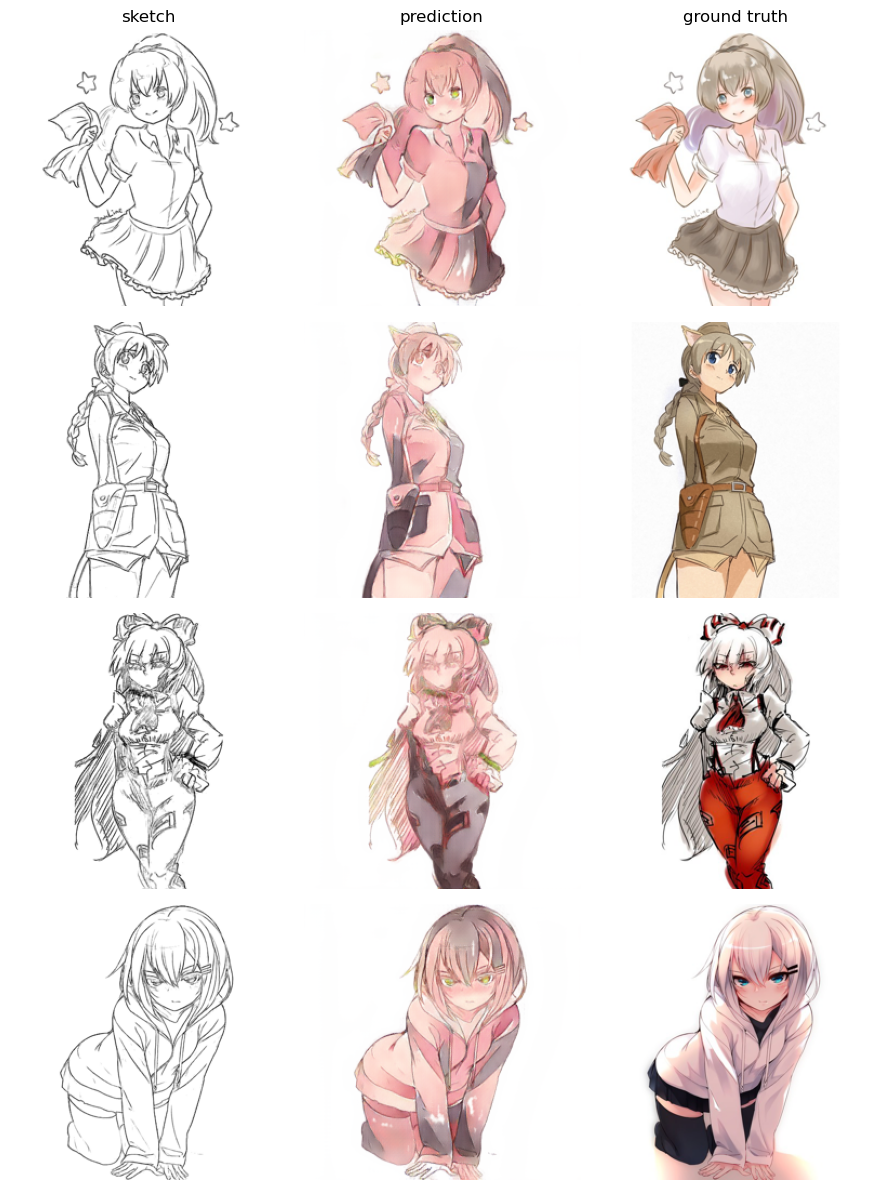

In [6]:
import torch

trainer.load_checkpoint("best.pt")
trainer._set_train_mode(False)

batch = next(iter(test_loader))
with torch.no_grad():
    fake_color = trainer.generate(batch["sketch"])

qualitative_grid(
    sketch=batch["sketch"],
    prediction=fake_color,
    target=batch["color"],
    n_rows=4,
    save_path=f"{FIGURES_DIR}/qualitative_grid.png",
)

## Quantitative metrics

FID, SSIM, PSNR and LPIPS on the full test set.

In [7]:
metrics = evaluate_model(
    generator=trainer.G_s2c,
    test_loader=test_loader,
    device="cuda",
    fid_dir="../results/fid/cyclegan",
)

print("\n=== CycleGAN — test metrics ===")
for k, v in metrics.items():
    print(f"  {k.upper():5s}: {v:.4f}")

# Persist for the cross-variant comparison
import json
with open(f"{TABLES_DIR}/cyclegan_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print(f"\nSaved to {TABLES_DIR}/cyclegan_metrics.json")

/home/mmondo/miniconda3/envs/anime-colorization/lib/python3.10/site-packages/torchmetrics/functional/image/lpips.py:332: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.l


=== CycleGAN — test metrics ===
  PSNR : 14.6617
  SSIM : 0.7845
  LPIPS: 0.2184
  FID  : 48.0443

Saved to ../results/tables/cyclegan_metrics.json
